In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam

In [2]:
df = pd.read_csv("/content/Electric_Production.csv")

df["DATE"] = pd.to_datetime(df["DATE"], format="%m-%d-%Y")
df = df.sort_values("DATE")

df.head()

,DATE,Value
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151


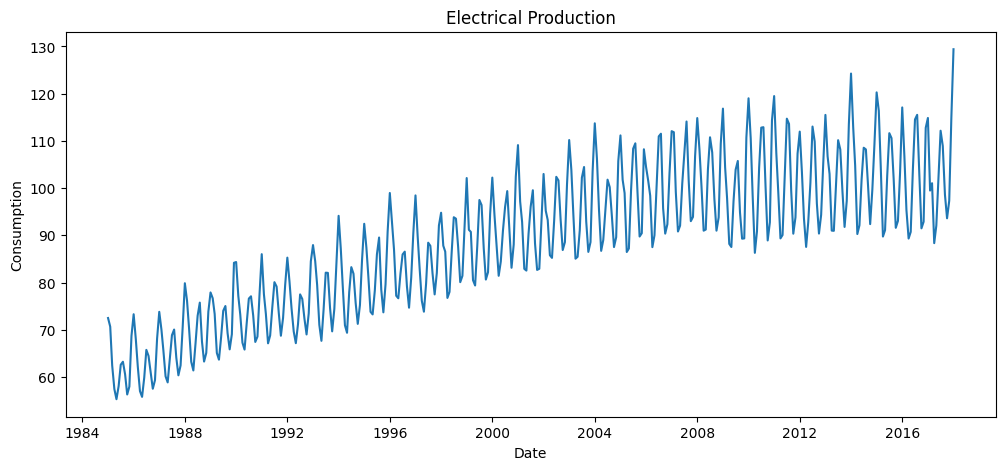

In [3]:
plt.figure(figsize=(12,5))
plt.plot(df["DATE"], df["Value"])
plt.title("Electrical Production")
plt.xlabel("Date")
plt.ylabel("Consumption")
plt.show()

In [4]:
values = df[["Value"]].values

scaler = MinMaxScaler()
scaled = scaler.fit_transform(values)

In [5]:
SEQ_LEN = 24   # last 24 months used to predict next month

def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled, SEQ_LEN)

split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [6]:
rnn_model = Sequential([
    SimpleRNN(64, activation="tanh", input_shape=(SEQ_LEN, 1)),
    Dense(32, activation="relu"),
    Dense(1)
])

rnn_model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)

rnn_history = rnn_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - loss: 0.0232 - val_loss: 0.0058
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0052 - val_loss: 0.0068
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026 - val_loss: 0.0039
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0019 - val_loss: 0.0036
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0018 - val_loss: 0.0030
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0026 - val_loss: 0.0031
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0022 - val_loss: 0.0033
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 0.0039
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0015 - val_loss: 0.0028
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 

In [7]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    LSTM(32),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm_model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)

lstm_history = lstm_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 0.0563 - val_loss: 0.0418
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0167 - val_loss: 0.0180
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0122 - val_loss: 0.0176
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0116 - val_loss: 0.0190
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0114 - val_loss: 0.0177
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0120 - val_loss: 0.0177
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0114 - val_loss: 0.0174
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0110 - val_loss: 0.0197
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115 - val_loss: 0.0177
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0111 - val_loss: 0.0173
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0111 - val_loss: 0.0174
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step

In [8]:
gru_model = Sequential([
    GRU(64, return_sequences=True, input_shape=(SEQ_LEN, 1)),
    GRU(32),
    Dense(32, activation="relu"),
    Dense(1)
])

gru_model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)

gru_history = gru_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0699 - val_loss: 0.0226
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0169 - val_loss: 0.0274
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0147 - val_loss: 0.0218
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0140 - val_loss: 0.0226
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0127 - val_loss: 0.0192
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0125 - val_loss: 0.0188
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0119 - val_loss: 0.0191
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0115 - val_loss: 0.0213
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0112 - val_loss: 0.0170
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0108 - val_loss: 0.0167
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0106 - val_loss: 0.0173
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

In [9]:
def build_vit_model(seq_len=24, patch_size=4, projection_dim=64, num_heads=4):
    inputs = Input(shape=(seq_len, 1))

    patches = Conv1D(
        filters=projection_dim,
        kernel_size=patch_size,
        strides=patch_size
    )(inputs)

    num_patches = seq_len // patch_size

    positions = tf.range(start=0, limit=num_patches, delta=1)
    position_embedding = Embedding(
        input_dim=num_patches,
        output_dim=projection_dim
    )(positions)

    x = patches + position_embedding

    for _ in range(2):
        x1 = LayerNormalization()(x)

        attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=projection_dim
        )(x1, x1)

        x2 = Add()([attention, x])

        x3 = LayerNormalization()(x2)
        x3 = Dense(128, activation="relu")(x3)
        x3 = Dense(projection_dim)(x3)

        x = Add()([x3, x2])

    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation="relu")(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    return model

In [10]:
vit_model = build_vit_model()

vit_model.compile(
    optimizer=Adam(0.001),
    loss="mse"
)

vit_history = vit_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 485ms/step - loss: 0.3592 - val_loss: 0.0216
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0371 - val_loss: 0.0277
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0194 - val_loss: 0.0167
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0156 - val_loss: 0.0190
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0124 - val_loss: 0.0222
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0101 - val_loss: 0.0116
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0083 - val_loss: 0.0107
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0092 - val_loss: 0.0061
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0045 - val_loss: 0.0055
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0069 - val_loss: 0.0116
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0070 - val_loss: 0.0097
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - l

In [11]:
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "Vision Transformer": vit_model
}

results = []

for name, model in models.items():
    pred = model.predict(X_test)

    y_test_inv = scaler.inverse_transform(y_test)
    pred_inv = scaler.inverse_transform(pred)

    mae = mean_absolute_error(y_test_inv, pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))

    results.append([name, mae, rmse])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE"])
results_df

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 666ms/step


,Model,MAE,RMSE
0,RNN,2.690838,3.457711
1,LSTM,2.904955,3.894159
2,GRU,2.884007,3.741289
3,Vision Transformer,3.977750,5.225684


In [12]:
def forecast_next_10_years(model, data, seq_len=24, months=120):
    last_sequence = data[-seq_len:].copy()
    future_predictions = []

    for _ in range(months):
        input_seq = last_sequence.reshape(1, seq_len, 1)

        next_pred = model.predict(input_seq, verbose=0)[0][0]

        future_predictions.append(next_pred)

        last_sequence = np.append(last_sequence[1:], [[next_pred]], axis=0)

    future_predictions = np.array(future_predictions).reshape(-1, 1)
    future_predictions = scaler.inverse_transform(future_predictions)

    return future_predictions

In [13]:
future_dates = pd.date_range(
    start=df["DATE"].iloc[-1] + pd.DateOffset(months=1),
    periods=120,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "DATE": future_dates
})

for name, model in models.items():
    forecast_df[name] = forecast_next_10_years(model, scaled)

forecast_df.head()

,DATE,RNN,LSTM,GRU,Vision Transformer
0,2018-02-01,111.340469,110.775047,117.610085,108.705338
1,2018-03-01,98.590652,99.645073,106.016876,94.452827
2,2018-04-01,88.589783,88.801910,92.851273,89.284416
3,2018-05-01,92.225655,87.716415,91.245949,89.988174
4,2018-06-01,101.829933,100.924347,103.554100,99.815155


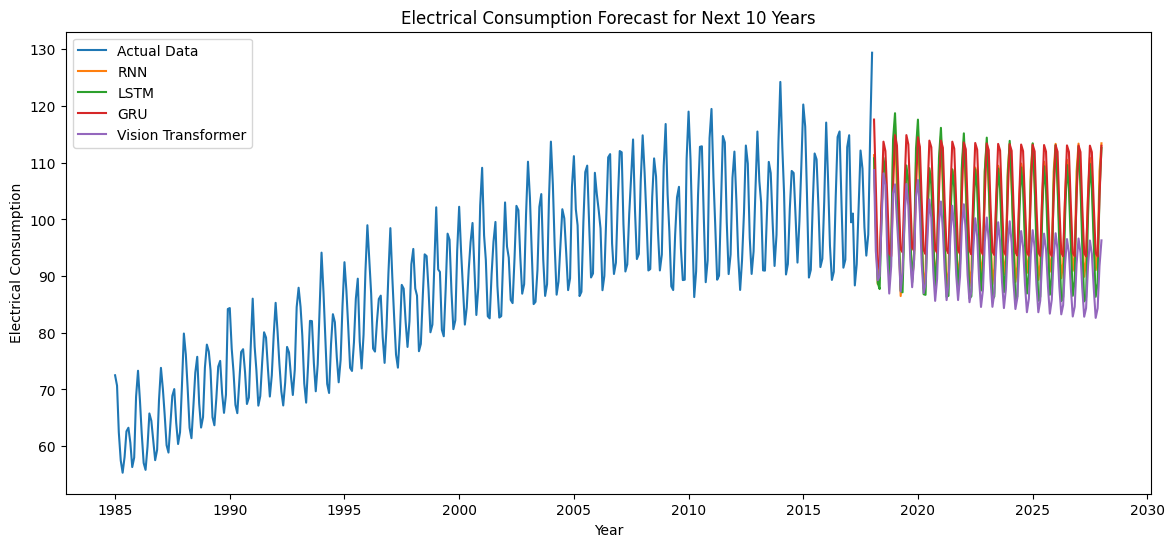

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df["DATE"], df["Value"], label="Actual Data")

for name in models.keys():
    plt.plot(forecast_df["DATE"], forecast_df[name], label=name)

plt.title("Electrical Consumption Forecast for Next 10 Years")
plt.xlabel("Year")
plt.ylabel("Electrical Consumption")
plt.legend()
plt.show()

In [15]:
forecast_df.to_csv("electric_consumption_10_year_forecast.csv", index=False)
forecast_df

,DATE,RNN,LSTM,GRU,Vision Transformer
0,2018-02-01,111.340469,110.775047,117.610085,108.705338
1,2018-03-01,98.590652,99.645073,106.016876,94.452827
2,2018-04-01,88.589783,88.801910,92.851273,89.284416
3,2018-05-01,92.225655,87.716415,91.245949,89.988174
4,2018-06-01,101.829933,100.924347,103.554100,99.815155
...,...,...,...,...,...
115,2027-09-01,98.150597,95.486473,102.337463,87.734680
116,2027-10-01,91.047668,86.348480,94.057510,82.631248
117,2027-11-01,93.830811,88.739784,93.451439,84.321304
118,2027-12-01,108.548843,104.840439,103.954277,91.782227
